In [16]:
from pathlib import Path
import time
import json
import re
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

from src.vlm_score import compute_vlm_score
from src.pixel_score import compute_all_metrics

DATASET_PATH = Path("/Users/jonathansickert/git/3DFrontBench/dataset")
RUNS_DIR = Path("/Users/jonathansickert/git/3DFrontBench/runs_gemma_no_ver")

In [ ]:
results_pixel = {}
results_vlm = {}

for run in RUNS_DIR.iterdir():

    target_path = DATASET_PATH / run.name / "color.png"
    results_pixel[run.name] = []
    results_vlm[run.name] = []

    for render_path in sorted(list(run.glob("*.png")), key=lambda x: int(x.stem.split("_")[-1])):

        vlm_score = compute_vlm_score(target_path, render_path)
        pixel_score = compute_all_metrics(target_path, render_path)

        results_pixel[run.name].append(pixel_score)
        results_vlm[run.name].append(vlm_score)

with open(f"../outputs/results_{RUNS_DIR.name}_pixel.json", "w") as f:
    json.dump(results_pixel, f, indent=2)

with open(f"../outputs/results_{RUNS_DIR.name}_vlm.json", "w") as f:
    json.dump(results_vlm, f, indent=2)

print(f"Saved outputs/results_{RUNS_DIR.name}_pixel.json and outputs/results_{RUNS_DIR.name}_vlm.json")


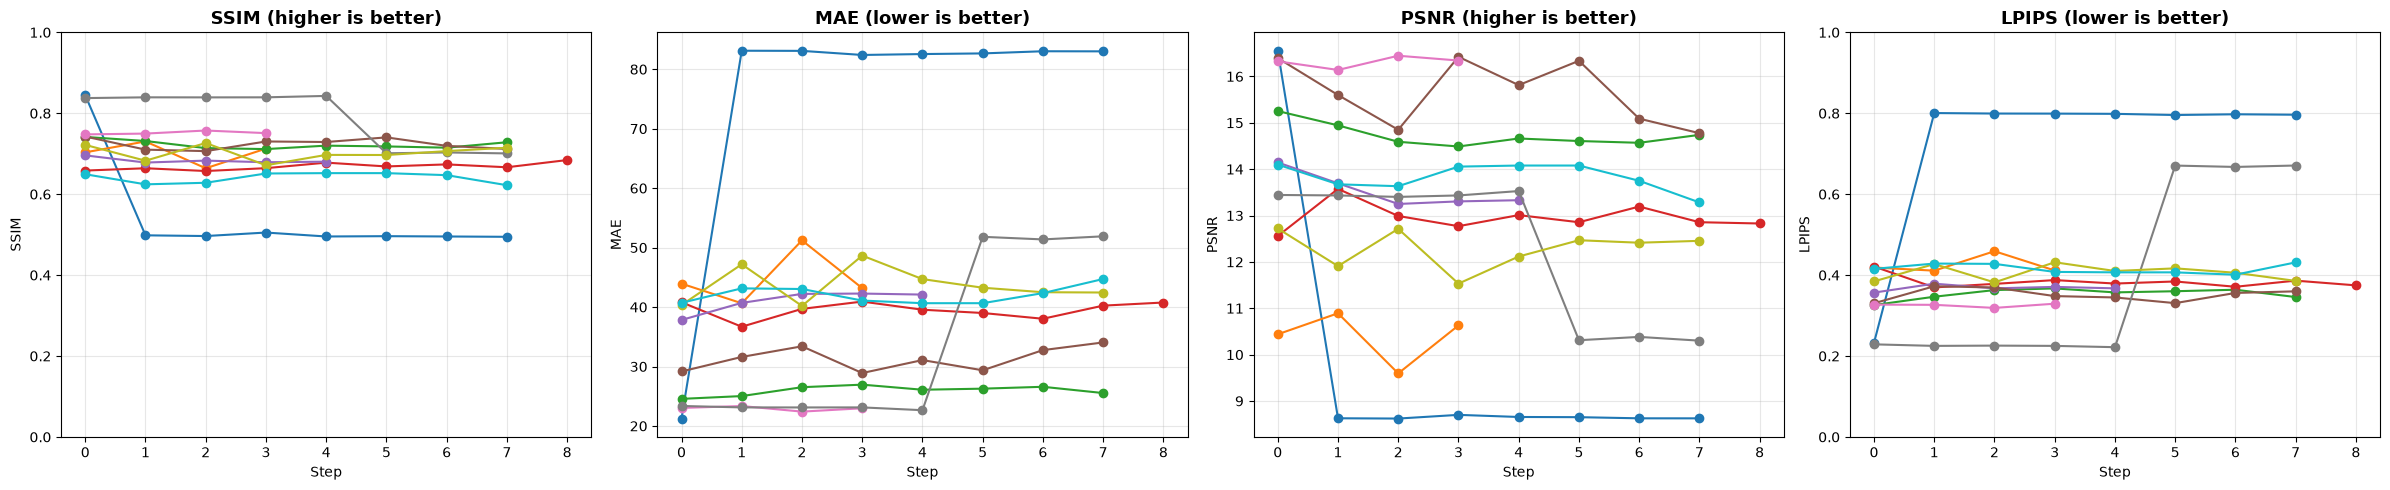

Saved ../outputs/results_runs_gemma_no_ver_pixel.png


In [20]:
OUTPUTS_DIR = Path("../outputs")
METRICS_JSON = OUTPUTS_DIR / f"results_{RUNS_DIR.name}_pixel.json"
PLOTD_PATH = OUTPUTS_DIR / f"results_{RUNS_DIR.name}_pixel.png"

METRICS = ["ssim", "mae", "psnr", "lpips"]
METRIC_LABELS = {
    "ssim": "SSIM (higher is better)",
    "mae": "MAE (lower is better)",
    "psnr": "PSNR (higher is better)",
    "lpips": "LPIPS (lower is better)",
}
METRIC_YLIM = {
    "ssim": (0, 1),
    "mae" : None,
    "psnr": None,
    "lpips": (0, 1),
}

with open(METRICS_JSON) as f:
    results_clean = json.load(f)

colors = cm.tab10(np.linspace(0, 1, len(results_clean)))

fig, axes = plt.subplots(1, len(METRICS), figsize=(6 * len(METRICS), 5))

for ax, metric in zip(axes, METRICS):
    for (run_name, run_data), color in zip(sorted(results_clean.items()), colors):
        if not run_data:
            continue

        steps = range(len(run_data))
        vals = [step_data[metric] for step_data in run_data]

        short_name = re.sub(r"^[0-9a-f-]+_", "", run_name)
        ax.plot(steps, vals, marker="o", label=short_name, color=color)

    ax.set_title(METRIC_LABELS[metric], fontsize=13, fontweight="bold")
    ax.set_xlabel("Step")
    ax.set_ylabel(metric.upper())
    if METRIC_YLIM[metric] is not None:
        ax.set_ylim(*METRIC_YLIM[metric])
    # ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(PLOTD_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {PLOTD_PATH}")


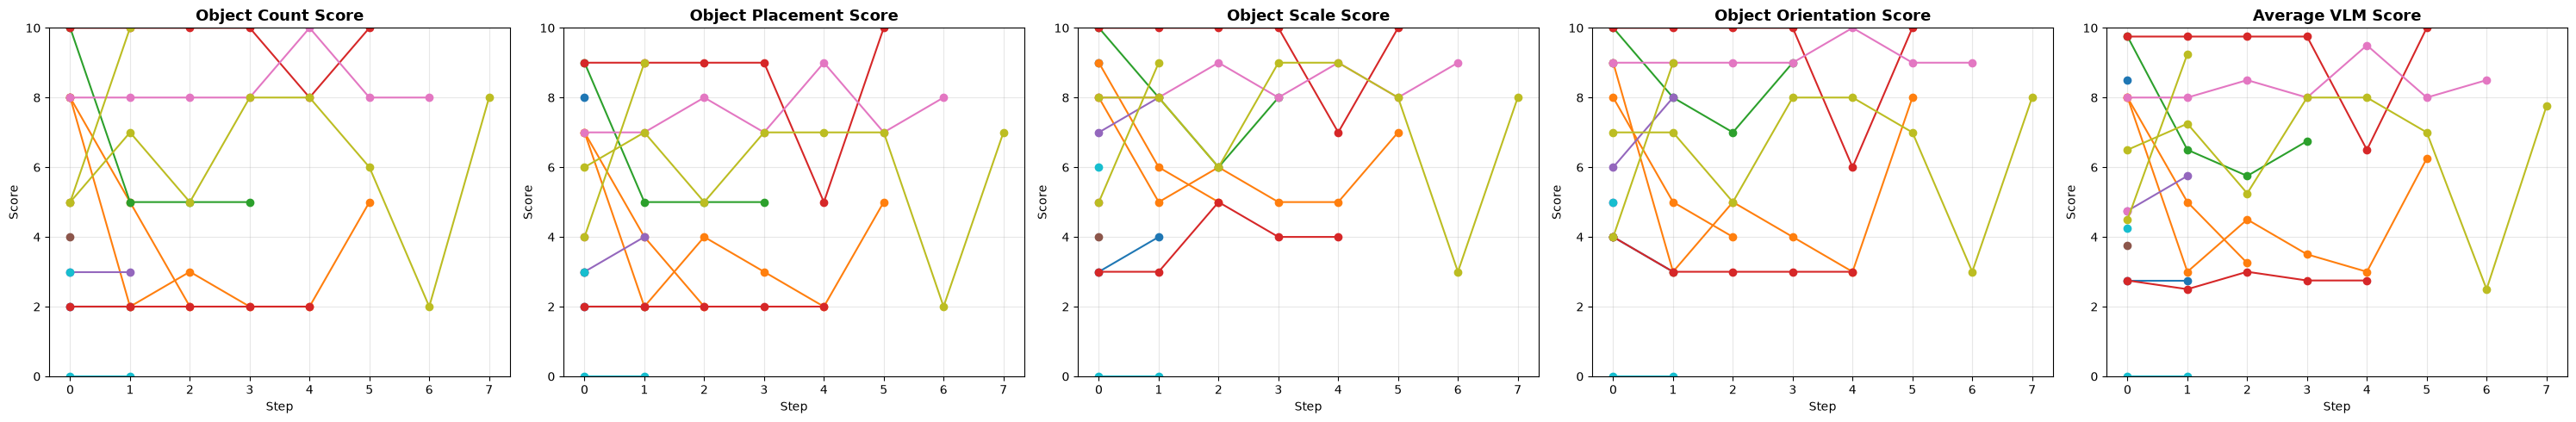

Saved ../outputs/results_runs_kimi_vlm.png


In [24]:
RUNS_DIR = Path("/Users/jonathansickert/git/3DFrontBench/runs_kimi")

OUTPUTS_DIR = Path("../outputs")
METRICS_JSON = OUTPUTS_DIR / f"results_{RUNS_DIR.name}_vlm.json"
PLOTD_PATH = OUTPUTS_DIR / f"results_{RUNS_DIR.name}_vlm.png"

VLM_METRICS = ["object_count", "object_placement", "object_scale", "object_orientation", "average"]
VLM_METRIC_LABELS = {
    "object_count": "Object Count Score",
    "object_placement": "Object Placement Score",
    "object_scale": "Object Scale Score",
    "object_orientation": "Object Orientation Score",
    "average": "Average VLM Score",
}
VLM_METRIC_YLIM = {
    "object_count": (0, 10),
    "object_placement": (0, 10),
    "object_scale": (0, 10),
    "object_orientation": (0, 10),
    "average": (0, 10),
}

with open(METRICS_JSON) as f:
    vlm_results = json.load(f)

colors = cm.tab10(np.linspace(0, 1, len(vlm_results)))

fig, axes = plt.subplots(1, len(VLM_METRICS), figsize=(6 * len(VLM_METRICS), 5))

for ax, metric in zip(axes, VLM_METRICS):
    for (run_name, run_data), color in zip(sorted(vlm_results.items()), colors):
        if not run_data:
            continue

        steps = range(len(run_data))
        scores = [json.loads(step_data[0]) for step_data in run_data]
        if metric == "average":
            vals = [np.mean([s[m] for m in VLM_METRICS[:-1]]) for s in scores]
        else:
            vals = [s[metric] for s in scores]

        short_name = re.sub(r"^[0-9a-f-]+_", "", run_name)
        ax.plot(steps, vals, marker="o", label=short_name, color=color)

    ax.set_title(VLM_METRIC_LABELS[metric], fontsize=13, fontweight="bold")
    ax.set_xlabel("Step")
    ax.set_ylabel("Score")
    if VLM_METRIC_YLIM[metric] is not None:
        ax.set_ylim(*VLM_METRIC_YLIM[metric])
    # ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(PLOTD_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {PLOTD_PATH}")


## Comparison

In [37]:
import json

def load_vlm_results(file_path):
    with open(file_path) as file:
        results = json.load(file)
        results = {k.split("_")[-1]: v for k, v in results.items()}
        results = {k: [json.loads(x[0]) for x in v] for k, v in results.items() if len(v) > 0}
    return results

relevant_metrics = ["object_count", "object_placement", "object_scale", "object_orientation"]

with open("/Users/jonathansickert/git/3DFrontBench/outputs/results_runs_gemma_pixel.json") as file:
    results_pixel_gemma = json.load(file)
    results_pixel_gemma = {k.split("_")[-1]: v for k, v in results_pixel_gemma.items()}

with open("/Users/jonathansickert/git/3DFrontBench/outputs/results_runs_kimi_pixel.json") as file:
    results_pixel_kimi = json.load(file)
    results_pixel_kimi = {k.split("_")[-1]: v for k, v in results_pixel_kimi.items()}

with open("/Users/jonathansickert/git/3DFrontBench/outputs/results_runs_gemma_no_ver_pixel.json") as file:
    results_pixel_gemma_no_ver = json.load(file)
    results_pixel_gemma_no_ver = {k.split("_")[-1]: v for k, v in results_pixel_gemma_no_ver.items()}


results_vlm_gemma = load_vlm_results("/Users/jonathansickert/git/3DFrontBench/outputs/results_runs_gemma_vlm.json")
results_vlm_kimi = load_vlm_results("/Users/jonathansickert/git/3DFrontBench/outputs/results_runs_kimi_vlm.json")
results_vlm_gemma_no_ver = load_vlm_results("/Users/jonathansickert/git/3DFrontBench/outputs/results_runs_gemma_no_ver_vlm.json")


human_evaluation_gemma = {
    "LivingDiningRoom-10290" : (2, 2),
    "LivingDiningRoom-4293" : (6, 4),
    "Library-35224": (2, 2),
    "LivingDiningRoom-89516" : (3, 3),
    "Corridor-20684" : (7, 7),
    "LivingRoom-9915" : (8, 8),
    "LivingDiningRoom-44815" : (1, 1),
    "LivingDiningRoom-209062" : (3, 2),
    "LivingRoom-2922" : (2, 1),
}


human_evaluation_kimi = {
    "LivingDiningRoom-12554" : (4, 3),
    "LivingDiningRoom-10290" : (2, 2),
    "MasterBedroom-14403" : (3, 2),
    "LivingDiningRoom-180855" : (3, 3),
    "MasterBedroom-5966" : (2, 2),
    "LivingDiningRoom-48379" : (6, 5),
    "LivingDiningRoom-847" : (2, 1),
    "LivingDiningRoom-9326" : (3, 1),
    "LivingDiningRoom-8149" : (7, 5),
    "LivingDiningRoom-89516" : (2, 4),
    "LivingRoom-38165" : (3, 3),
    "Corridor-20684" : (6, 5),
}

human_evaluation_gemma_no_ver = {
    "LivingDiningRoom-10290" : (0, 0),
    "LivingDiningRoom-4293" : (3, 2),
    "Hallway-34943" : (1, 2),
    "Library-35224" : (0, 0),
    "LivingDiningRoom-89516" : (0, 0),
    "Corridor-20684" : (5, 4),
    "LivingRoom-9915" : (7, 7),
    "LivingDiningRoom-44815" : (1, 1),
    "LivingDiningRoom-209062" : (1, 2),
    "LivingRoom-2922" : (2, 1),
}


avg_human_eval_gemma = {k: sum(v)/len(v) for k, v in human_evaluation_gemma.items()}
avg_human_eval_kimi = {k: sum(v)/len(v) for k, v in human_evaluation_kimi.items()}
avg_human_eval_gemma_no_ver = {k: sum(v)/len(v) for k, v in human_evaluation_gemma_no_ver.items()}

last_vlm_eval_gemma = {k : v[-1] for k, v in results_vlm_gemma.items()}
last_vlm_eval_kimi = {k : v[-1] for k, v in results_vlm_kimi.items()}
last_vlm_eval_gemma_no_ver = {k : v[-1] for k, v in results_vlm_gemma_no_ver.items()}

avg_vlm_eval_gemma = {k : np.mean([v[m] for m in relevant_metrics]) for k, v in last_vlm_eval_gemma.items()}
avg_vlm_eval_kimi = {k : np.mean([v[m] for m in relevant_metrics]) for k, v in last_vlm_eval_kimi.items()}
avg_vlm_eval_gemma_no_ver = {k : np.mean([v[m] for m in relevant_metrics]) for k, v in last_vlm_eval_gemma_no_ver.items()}

In [46]:
import pandas as pd

def build_overview_df(avg_human, avg_vlm, run_name):
    scenes = sorted(set(avg_human) & set(avg_vlm))
    return pd.DataFrame({
        "run": run_name,
        "scene": scenes,
        "human_avg": [avg_human[s] for s in scenes],
        "vlm_last_step_avg": [avg_vlm[s] for s in scenes],
    })

overview_df = pd.concat([
    build_overview_df(avg_human_eval_gemma, avg_vlm_eval_gemma, "gemma"),
    build_overview_df(avg_human_eval_kimi, avg_vlm_eval_kimi, "kimi"),
    build_overview_df(avg_human_eval_gemma_no_ver, avg_vlm_eval_gemma_no_ver, "gemma_no_ver"),
], ignore_index=True)

overview_df["abs_diff"] = (overview_df["human_avg"] - overview_df["vlm_last_step_avg"]).abs()
overview_df["vlm_higher"] = overview_df["vlm_last_step_avg"] > overview_df["human_avg"]
overview_df

,run,scene,human_avg,vlm_last_step_avg,abs_diff,vlm_higher
0,gemma,Corridor-20684,7.0,7.25,0.25,True
1,gemma,Library-35224,2.0,3.00,1.00,True
2,gemma,LivingDiningRoom-10290,2.0,2.75,0.75,True
3,gemma,LivingDiningRoom-209062,2.5,5.00,2.50,True
4,gemma,LivingDiningRoom-4293,5.0,7.75,2.75,True
5,gemma,LivingDiningRoom-44815,1.0,0.00,1.00,False
6,gemma,LivingDiningRoom-89516,3.0,0.00,3.00,False
7,gemma,LivingRoom-2922,1.5,0.00,1.50,False
8,gemma,LivingRoom-9915,8.0,7.75,0.25,False
9,kimi,Corridor-20684,5.5,6.75,1.25,True


In [47]:
overview_df.groupby("run").agg(
    {
        "abs_diff": ["mean"],
        "vlm_higher": ["sum", "mean"],
    }
)

abs_diff vlm_higher          
                  mean        sum      mean
run                                        
gemma         1.444444          5  0.555556
gemma_no_ver  4.000000          9  0.900000
kimi          2.666667         12  1.000000